# **7. ML - Clustering**

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MeanShift, OPTICS, estimate_bandwidth
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.model_selection import ParameterGrid
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import umap.umap_ as umap

/home/kyke/.var/app/com.visualstudio.code/cache/pypoetry/virtualenvs/marketing-ml-a6pcPZMr-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-08 21:24:31.183140: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-08 21:24:31.363390: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744140271.431622 1243988 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

In [2]:
# Cargar el archivo CSV
df = pd.read_csv('../data/processed/campana_marketing.csv', parse_dates=['Dt_Customer'])

# Convertir la columna 'Income' de float64 a int64
df['Income'] = df['Income'].astype('int64')

## Selección de variables útiles para clustering
### Variables candidatas para ser eliminadas:
- **`ID`**: identificador inútil para clustering.
- **`Dt_Customer`**: además de que es de tipo datetime, ya creamos `Days` y `Seniority` que lo resumen.
- **`Year_Birth`**: ya tenemos `Age`, que es más útil y comprensible.
- **De `AcceptedCmp1` a `AcceptedCmp5`**: ya lo hemos resumido con `AcceptedCmp`.
- **`Response`**: está relacionado con el target de campañas, más supervisado.
- **`Complain`**: no es nuestro objetivo, por el momento, pero sería muy útil para una segmentación churn (o segmentación de abandono). Dejamos abierta la posibilidad de que en un futuro se pueda hacer un análisis que clasifica a los clientes según su riesgo o probabilidad de dejar un producto/servicio (churn rate), permitiendo diseñar estrategias personalizadas para retenerlos.
- **`Days`**: si ya usamos `Seniority, es redundante.
- **`Kidhome` y `Teenhome`**: ya están simplificados en `Child_Home`, se eliminarán para no aumentar la granularidad.

In [3]:
# Columnas a excluir (según tu lista)
excluded_columns = ['ID', 'Dt_Customer', 'Year_Birth', 'AcceptedCmp1', 
                    'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 
                    'AcceptedCmp5', 'Response', 'Complain', 'Days', 'Kidhome', 'Teenhome']

# Generar la lista final filtrando las columnas no deseadas
features_for_clustering = [col for col in df.columns if col not in excluded_columns]

print(features_for_clustering)

['Education', 'Marital_Status', 'Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Seniority', 'Child_Home', 'AcceptedCmp', 'Spent', 'Age']


## Tres versiones con escalados distintos
Para que sea **limpio y flexible** y como queremos comparar KMeans, Hierarchical, DBSCAN, OPTICS y MeanShift con pipelines similares, haremos lo siguiente:
1. `StandardScaler` para:
    - **KMeans**: porque usa distancia euclídea.
    - **Hierarchical**: también es sensible a escalas.
2. `MinMaxScaler` para:
    - **MeanShift**: porque depende de distancias (bandwidth).
    - **OPTICS**: porque depende de distancias (bandwidth).
3. `RobustScaler` para:
    - **DBSCAN**: porque se veía afectado por valores extremos.

In [4]:
# Solo las columnas seleccionadas
X = df[features_for_clustering].copy()

# Tres versiones escaladas
X_std = StandardScaler().fit_transform(X)
X_minmax = MinMaxScaler().fit_transform(X)
X_robust = RobustScaler().fit_transform(X)

## Reducción de Dimensionalidad con PCA

### ¿Por qué aplicar PCA?

Para mejorar el rendimiento de los algoritmos de clustering y reducir el ruido en los datos, aplicamos **PCA (Análisis de Componentes Principales)**. Esta técnica permite:

- **Reducir la dimensionalidad** del dataset mientras se conserva la estructura esencial de los datos.
- **Eliminar redundancia o colinealidad** entre variables altamente correlacionadas.
- **Facilitar la separación y formación de clusters**, ayudando a modelos sensibles a la dimensión.
- **Reducir el tiempo de cómputo**, especialmente en algoritmos que escalan mal con muchas variables.

### Selección de número de componentes

En lugar de definir un umbral de varianza explicada (como 90% o 95%), optamos por una reducción **fija a 3 dimensiones** (`n_components=3`) para todos los modelos. Esta decisión se basa en los siguientes motivos:

- **Estabilidad y simplicidad**: todos los modelos trabajan con una representación homogénea y compacta.
- **Facilita visualizaciones** posteriores en 2D o 3D.
- **Mejor control de complejidad**: evitamos incluir dimensiones que aportan poca información útil para el clustering.

### Escalado previo a la PCA

Como paso previo, aplicamos escalado a las variables originales:
- `StandardScaler`: para modelos como **KMeans** y **Hierarchical**.
- `MinMaxScaler`: para modelos como **OPTICS** y **MeanShift**.

A cada versión escalada se le aplicará **PCA con 3 componentes**, generando dos matrices reducidas:
- `X_std_pca`: para modelos con `StandardScaler`.
- `X_minmax_pca`: para modelos con `MinMaxScaler`.

In [5]:
# PCA para la versión escalada con StandardScaler
pca_std = PCA(n_components=3)  # Reducción fija a 3 dimensiones
X_std_pca = pca_std.fit_transform(X_std)

# PCA para la versión escalada con MinMaxScaler
pca_minmax = PCA(n_components=3)
X_minmax_pca = pca_minmax.fit_transform(X_minmax)

In [6]:
# Convertir a DataFrame con nombres de columnas descriptivos
X_std_pca_df = pd.DataFrame(X_std_pca, columns=['PC1', 'PC2', 'PC3'])
X_minmax_pca_df = pd.DataFrame(X_minmax_pca, columns=['PC1', 'PC2', 'PC3'])

X_std_pca_df.describe().T

,count,mean,std,min,25%,50%,75%,max
PC1,2212.0,5.781993e-17,2.682494,-5.154933,-2.424942,-0.779764,2.299721,7.622542
PC2,2212.0,-6.424437e-18,1.394884,-3.557769,-0.981725,-0.237154,0.872199,5.268495
PC3,2212.0,-2.087942e-17,1.218487,-4.752683,-0.805187,-0.035613,0.838741,3.994613


In [7]:
X_minmax_pca_df.describe().T

,count,mean,std,min,25%,50%,75%,max
PC1,2212.0,0.000000e+00,0.602582,-1.719580,-0.412084,0.164286,0.539041,0.840787
PC2,2212.0,-9.315434e-17,0.478122,-0.713197,-0.623797,0.310157,0.358964,0.487907
PC3,2212.0,1.606109e-17,0.384218,-0.732274,-0.099221,-0.011215,0.122966,1.058818


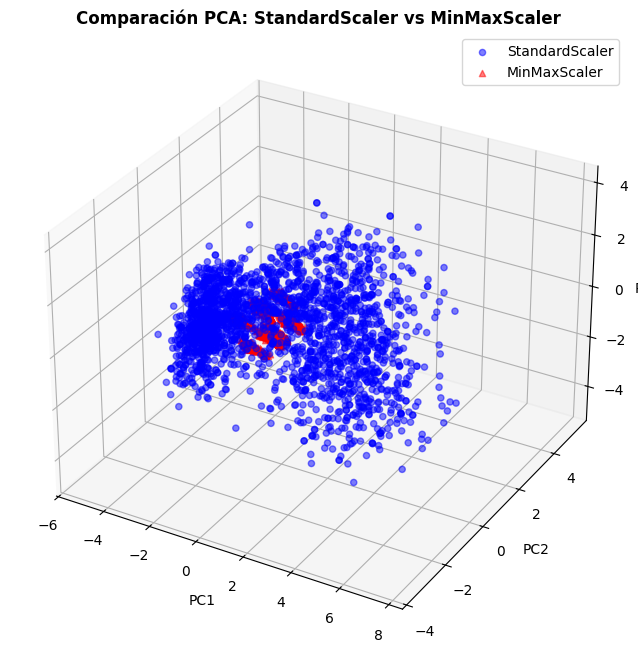

In [8]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# StandardScaler
ax.scatter(X_std_pca_df['PC1'], X_std_pca_df['PC2'], X_std_pca_df['PC3'],
          c='blue', marker='o', alpha=0.5, label='StandardScaler')

# MinMaxScaler
ax.scatter(X_minmax_pca_df['PC1'], X_minmax_pca_df['PC2'], X_minmax_pca_df['PC3'],
          c='red', marker='^', alpha=0.5, label='MinMaxScaler')

ax.set_title('Comparación PCA: StandardScaler vs MinMaxScaler', fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend()

plt.show()

### Preprocesamiento específico para DBSCAN

Para mejorar el desempeño de DBSCAN, que se veía afectado por datos ruidosos y valores extremos, aplicamos un preprocesamiento alternativo:

- `RobustScaler`: para manejar mejor los outliers.
- `UMAP`: para preservar la estructura local de los datos en menos dimensiones (más adecuado para modelos basados en densidad).

In [9]:
# Reducción de dimensionalidad con UMAP
umap_model = umap.UMAP(n_components=3, random_state=42)
X_umap = umap_model.fit_transform(X_robust)

/home/kyke/.var/app/com.visualstudio.code/cache/pypoetry/virtualenvs/marketing-ml-a6pcPZMr-py3.12/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/kyke/.var/app/com.visualstudio.code/cache/pypoetry/virtualenvs/marketing-ml-a6pcPZMr-py3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


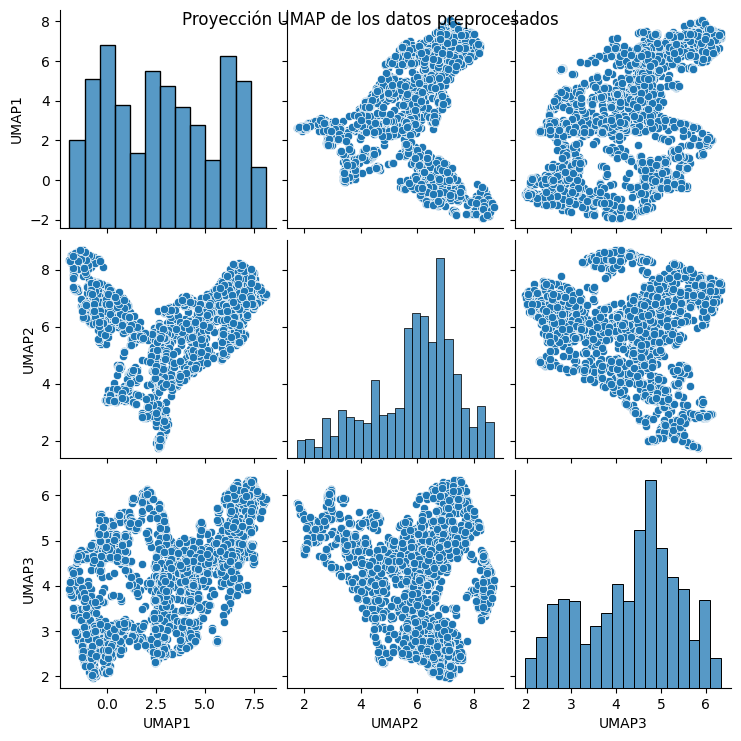

In [10]:
umap_df = pd.DataFrame(X_umap, columns=['UMAP1', 'UMAP2', 'UMAP3'])
sns.pairplot(umap_df)
plt.suptitle('Proyección UMAP de los datos preprocesados')
plt.show()

### **Justificación del Mínimo de 3 Segmentos**  

**Contexto del Negocio**:  
El cliente ha expresado la necesidad de identificar **mínimo 3 perfiles diferenciados** en su base de clientes para:  
- Diseñar estrategias de marketing personalizadas (ej: alto/medio/bajo valor).  
- Optimizar recursos asignando tácticas distintas a cada grupo.  
- Evitar soluciones demasiado genéricas (ej: solo 2 clusters podrían ocultar nuances clave).  

**Decisión Técnica**:  
Para garantizar resultados accionables, hemos forzado a los algoritmos a buscar **al menos 3 clusters** mediante:
1. **El rango de `n_clusters`**: para KMeans y AgglomerativeClustering (Hierarchical) que varíe a partir de 3. 
2. **Validación durante el entrenamiento**:  
   ```python
   if len(np.unique(labels[labels != -1])) < 3:  # Excluye configs con <3 clusters válidos
       continue
   ```  
3. **Filtrado de modelos**: Solo se almacenan soluciones con ≥3 segmentos (ver columnas `Num Clusters` en los resultados).  

**Riesgos Mitigados**:  
- **Sobre-segmentación**: Controlada por métricas como Silhouette Score (equilibrio entre cohesión y separación).  
- **Ruido en DBSCAN/OPTICS**: Exigimos que ≥60% de los puntos pertenezcan a clusters válidos (no sean `-1`).  

## Selección de modelos

In [11]:
models = {
    'KMeans': (KMeans(), X_std_pca),  # StandardScaler + PCA
    'Hierarchical': (AgglomerativeClustering(), X_std_pca),  # StandardScaler + PCA
    'MeanShift': (MeanShift(), X_minmax_pca),  # MinMaxScaler + PCA
    'OPTICS': (OPTICS(), X_minmax_pca),  # MinMaxScaler + PCA
    'DBSCAN': (DBSCAN(), X_umap)  # RobustScaler + UMAP
}

## Análisis preliminar para KMeans


Análisis del Codo para KMeans


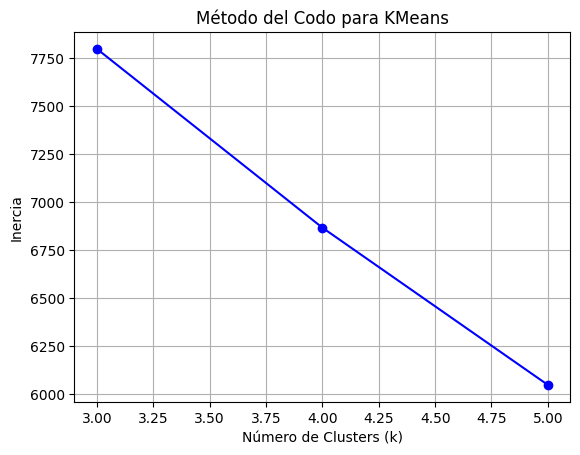

Sugerencia para KMeans: n_clusters = 5


In [12]:
print("\nAnálisis del Codo para KMeans")
inertias = []
range_k = range(3, 6)

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_std_pca)
    inertias.append(kmeans.inertia_)

# Gráfico
plt.plot(range_k, inertias, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para KMeans')
plt.grid()
plt.show()

# Sugerencia automática de k (usando la "regla del codo" programática)
differences = np.diff(inertias)
optimal_k = range_k[np.argmax(differences)] + 1  # +1 porque np.diff reduce el array
print(f"Sugerencia para KMeans: n_clusters = {optimal_k}")

## Análisis preliminar para Hierarchical

Análisis del Codo/Dendrograma para determinar rango óptimo de clusters


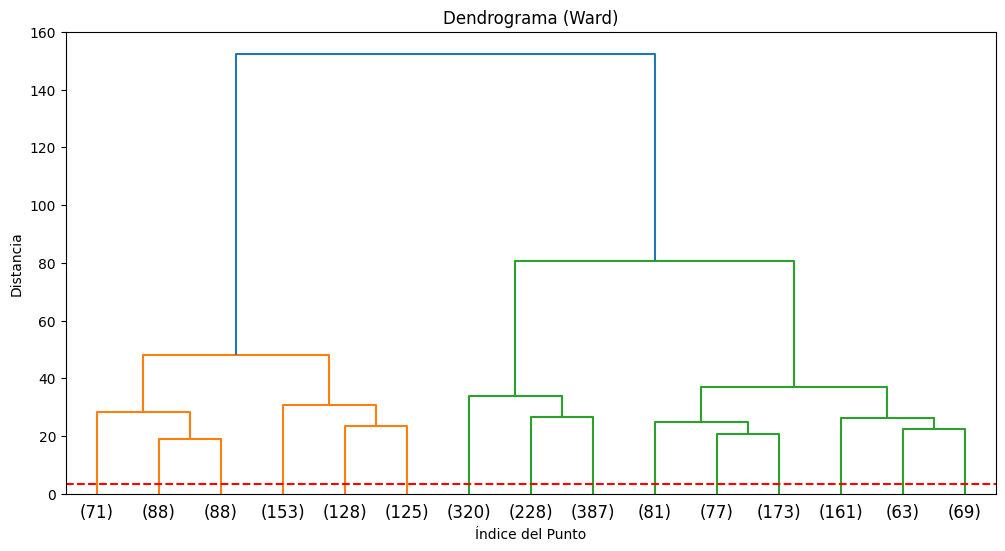

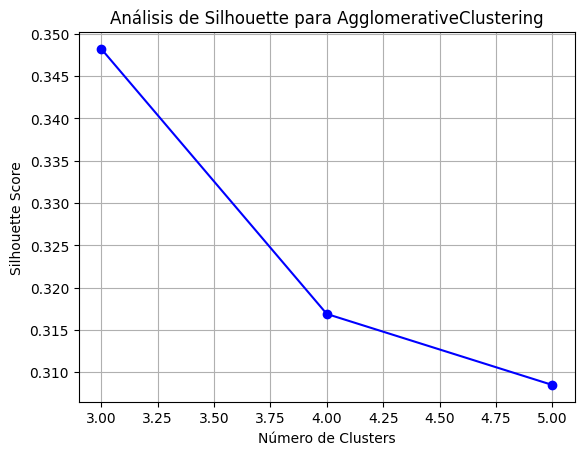


Sugerencia: Probar n_clusters entre 3 y 4 en el GridSearch


In [13]:
print("Análisis del Codo/Dendrograma para determinar rango óptimo de clusters")

# Método 1: Dendrograma clásico (scipy)
plt.figure(figsize=(12, 6))
Z = linkage(X_std_pca, method='ward', metric='euclidean')
dendrogram(Z, truncate_mode='lastp', p=15, show_leaf_counts=True)
plt.axhline(y=3.5, color='r', linestyle='--')  # Línea de corte sugerida
plt.title("Dendrograma (Ward)")
plt.xlabel("Índice del Punto")
plt.ylabel("Distancia")
plt.show()

# Método 2: Silhouette Analysis (sklearn)
from sklearn.metrics import silhouette_score

range_n_clusters = range(3, 6) # Evalúa solo 3, 4 y 5 clusters
silhouette_scores = []

for n_clusters in range_n_clusters:
    clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    labels = clusterer.fit_predict(X_std_pca)
    silhouette_scores.append(silhouette_score(X_std_pca, labels))

optimal_clusters = range_n_clusters[np.argmax(silhouette_scores)]
margin = 1  # Explorar ±1 alrededor del óptimo
n_clusters_range = list(range(
    max(3, optimal_clusters - margin), 
    min(6, optimal_clusters + margin + 1)
))

plt.plot(range_n_clusters, silhouette_scores, 'bo-')
plt.xlabel("Número de Clusters")
plt.ylabel("Silhouette Score")
plt.title("Análisis de Silhouette para AgglomerativeClustering")
plt.grid()
plt.show()

# Sugerencia basada en resultados
optimal_clusters = range_n_clusters[np.argmax(silhouette_scores)]
print(f"\nSugerencia: Probar n_clusters entre {max(3, optimal_clusters-1)} y {optimal_clusters+1} en el GridSearch")

## Ajuste preliminar de `bandwidth` para MeanShift

In [14]:
bandwidth = estimate_bandwidth(X_minmax_pca, quantile=0.2)  # Ajustar quantile
print(f"Bandwidth sugerido: {bandwidth:.2f}")

Bandwidth sugerido: 0.65


## Análisis preliminar para OPTICS

eps óptimo estimado: 0.215


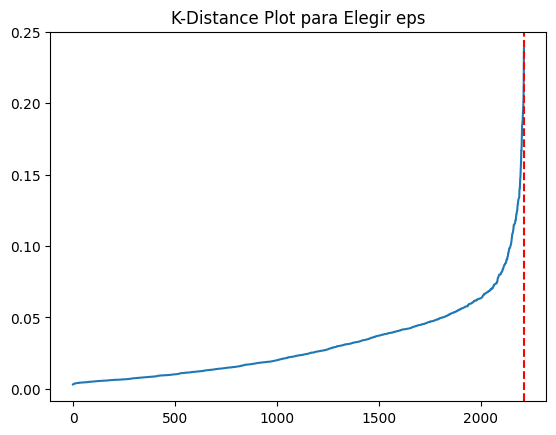

In [15]:
# Calcular distancias al 5to vecino más cercano (ajusta n_neighbors según tu dataset)
nbrs = NearestNeighbors(n_neighbors=5).fit(X_minmax_pca)
distances, _ = nbrs.kneighbors(X_minmax_pca)
k_distances = np.sort(distances[:, -1])

# Encontrar el "codo" para eps (punto de máxima curvatura)
differences = np.diff(k_distances, 2)  # Segunda derivada
optimal_idx = np.argmax(differences) + 1  # +1 por el diff
optimal_eps = k_distances[optimal_idx]

print(f"eps óptimo estimado: {optimal_eps:.3f}")
plt.plot(k_distances)
plt.axvline(x=optimal_idx, color='r', linestyle='--')
plt.title("K-Distance Plot para Elegir eps")
plt.show()


Análisis de distancia para OPTICS


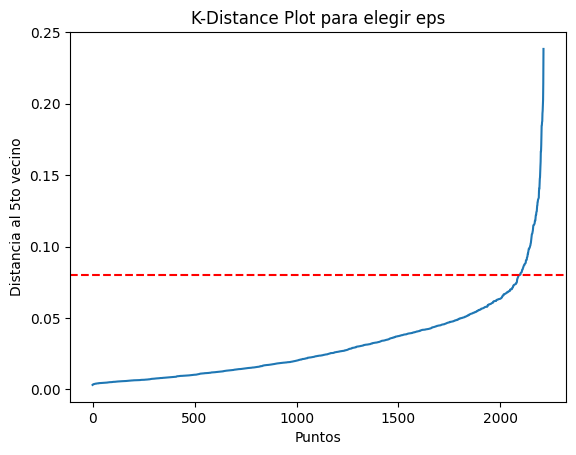

In [16]:
print("\nAnálisis de distancia para OPTICS")
nn = NearestNeighbors(n_neighbors=5).fit(X_minmax_pca)
distances, _ = nn.kneighbors(X_minmax_pca)
distances = np.sort(distances[:, -1], axis=0)

plt.plot(distances)
plt.xlabel('Puntos')
plt.ylabel('Distancia al 5to vecino')
plt.title('K-Distance Plot para elegir eps')
plt.axhline(y=0.08, color='r', linestyle='--')  # Ajusta este valor visualmente
plt.show()

### Cálculo Automático de eps (Basado en Distancias)

In [17]:
def calculate_optimal_eps(X, min_samples=5, percentil=95):
    """
    Calcula eps basado en la distancia al k-ésimo vecino (percentil elegido).
    Parámetros:
        - X: Datos escalados (usar X_minmax_pca para DBSCAN/OPTICS)
        - min_samples: Mismo valor que usas en DBSCAN/OPTICS (k-vecinos)
        - percentil: Percentil para seleccionar el valor de eps (ej: 95)
    """
    nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X)
    distances, _ = nbrs.kneighbors(X)
    k_distances = distances[:, -1]  # Distancia al k-ésimo vecino
    eps = np.percentile(k_distances, percentil)
    return round(eps, 2)

margin = 1.2  # Rango alred del valor óptimoedor
optimal_eps_optics = calculate_optimal_eps(X_minmax_pca, min_samples=5, percentil=95)
print(f"Valor calculado de eps para OPTICS: {optimal_eps}")
optimal_eps_dbscan = calculate_optimal_eps(X_umap, min_samples=5, percentil=95)
print(f"Valor calculado de eps para DBSCAN: {optimal_eps}")

Valor calculado de eps para OPTICS: 0.21461424531758294
Valor calculado de eps para DBSCAN: 0.21461424531758294


## Grid de hiperparámetros

In [18]:
param_grid = {
    'KMeans': {
    'n_clusters': list(range(max(3, optimal_k-1), min(6, optimal_k+2))), # Resultado del análisis del Codo
    'init': ['k-means++', 'random'],            # Inicializaciones posibles
    'n_init': [10, 20, 30],                     # Más reinicios mejora la estabilidad
    'max_iter': [300, 500],                     # Control sobre iteraciones
    'random_state': [42]
    },
    'Hierarchical': {
    'n_clusters': n_clusters_range,           # Resultado del análisis del Codo/Dendrograma
    'linkage': ['ward', 'complete', 'average'],  # Diferentes estilos de unión
    'metric': ['euclidean']      # 'ward' solo funciona con euclidean
    },
    'DBSCAN': {
    'eps': [optimal_eps_dbscan - margin, optimal_eps_dbscan, optimal_eps_dbscan + margin], # Radio de vecindad sacado anteriormente
    'min_samples': [4, 6, 8],                  # Densidad mínima
    # Regla práctica: Usamos min_samples ≥ dim + 1 (dim = dimensiones de tus datos). Para PCA con 3 componentes
    'metric': ['euclidean', 'manhattan'],       # Distancias comunes
    'algorithm': ['auto', 'ball_tree', 'kd_tree']  # Algoritmos internos
    },
    'MeanShift': {
    'bandwidth': [bandwidth * 0.8, bandwidth, bandwidth * 1.2],  # Bandwidth controla la ventana
    'bin_seeding': [True, False]                  # Afecta rendimiento en grandes datasets
    },
    'OPTICS': {
    'eps': [optimal_eps_optics - margin, optimal_eps_optics, optimal_eps_optics + margin], # Radio de vecindad sacado anteriormente
    'min_samples': [3, 5, 10],                   # Igual que DBSCAN
    'xi': [0.01, 0.05, 0.1],                     # Sensibilidad para extraer clusters
    'min_cluster_size': [0.03, 0.05, 0.1],       # En fracción o número absoluto
    'metric': ['euclidean', 'manhattan']         # Distancias
    }
}

## Loop de entrenamiento + Evaluación interna

In [19]:
# Diccionario para almacenar resultados y mejores modelos
results = {}
best_models = {}

for model_name, (model, X_data) in models.items():
    print(f"\nEvaluando: {model_name}")
    best_score = -1
    best_config = None
    best_model = None
    best_labels = None
    
    grid = ParameterGrid(param_grid[model_name])
    
    for params in tqdm(grid, desc=f"GridSearch {model_name}", leave=False):
        # Validación especial para Hierarchical: ward → metric debe ser euclidean
        if model_name == 'Hierarchical' and params['linkage'] == 'ward' and params['metric'] != 'euclidean':
            continue
        
        # Crear una nueva instancia del modelo con estos parámetros
        model_instance = model.set_params(**params)
        try:
            labels = model_instance.fit_predict(X_data)
            
            # --- Validaciones ---
            if model_name in ['DBSCAN', 'OPTICS']:
                labels_clean = labels[labels != -1]  # excluye ruido
                unique_clusters = np.unique(labels_clean)

                # Validar cantidad de clusters (entre 3 y 5)
                if len(unique_clusters) < 3 or len(unique_clusters) > 5:
                    continue

                # Validar ratio mínimo de puntos asignados (evitar exceso de ruido)
                valid_ratio = len(labels_clean) / len(labels)
                if valid_ratio < 0.6:
                    continue
            else:
                unique_clusters = np.unique(labels)
                if len(unique_clusters) < 3 or len(unique_clusters) > 5:
                    continue

            # --- Métricas ---
            silhouette = silhouette_score(X_data, labels)
            calinski = calinski_harabasz_score(X_data, labels)
            davies = davies_bouldin_score(X_data, labels)
            
            if silhouette > best_score:
                best_score = silhouette
                best_config = params
                best_model = model_instance
                best_labels = labels

        except Exception as e:
            # Saltar errores que puedan surgir (pocos vecinos, etc.)
            continue

    results[model_name] = {
        'Silhouette Score': round(best_score, 4),
        'Davies-Bouldin': round(davies, 4) if best_labels is not None else None,
        'Calinski-Harabasz': round(calinski, 4) if best_labels is not None else None,
        'Best Params': best_config,
        'Num Clusters': len(set(best_labels[best_labels != -1])) if best_labels is not None and model_name in ['DBSCAN', 'OPTICS']
                        else len(set(best_labels)) if best_labels is not None else 0
    }
    
    best_models[model_name] = best_model

# Convertir resultados a DataFrame
results_df = pd.DataFrame(results).T
results_df[['Silhouette Score', 'Davies-Bouldin', 'Calinski-Harabasz']] = (
    results_df[['Silhouette Score', 'Davies-Bouldin', 'Calinski-Harabasz']]
    .astype(float)
    .round(4)
)
results_df


Evaluando: KMeans



Evaluando: Hierarchical



Evaluando: MeanShift



Evaluando: OPTICS


GridSearch OPTICS:   0%|          | 0/162 [00:00<?, ?it/s]/home/kyke/.var/app/com.visualstudio.code/cache/pypoetry/virtualenvs/marketing-ml-a6pcPZMr-py3.12/lib/python3.12/site-packages/sklearn/cluster/_optics.py:1086: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]
GridSearch OPTICS:  34%|███▍      | 55/162 [00:01<00:01, 54.83it/s]/home/kyke/.var/app/com.visualstudio.code/cache/pypoetry/virtualenvs/marketing-ml-a6pcPZMr-py3.12/lib/python3.12/site-packages/sklearn/cluster/_optics.py:1086: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]
/home/kyke/.var/app/com.visualstudio.code/cache/pypoetry/virtualenvs/marketing-ml-a6pcPZMr-py3.12/lib/python3.12/site-packages/sklearn/cluster/_optics.py:1086: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]
GridSearch OPTICS:  38%|███▊      | 61/162 [00:06<00:15,  6.64it/


Evaluando: DBSCAN


,Silhouette Score,Davies-Bouldin,Calinski-Harabasz,Best Params,Num Clusters
KMeans,0.3015,1.2231,1596.9948,"{'init': 'k-means++', 'max_iter': 300, 'n_clus...",4
Hierarchical,0.3881,0.7835,693.0718,"{'linkage': 'average', 'metric': 'euclidean', ...",3
MeanShift,0.5010,0.8592,1363.1167,"{'bandwidth': 0.6457547751579795, 'bin_seeding...",5
OPTICS,0.4742,1.1063,1104.0040,"{'eps': 0.08, 'metric': 'manhattan', 'min_clus...",3
DBSCAN,-1.0000,NaN,NaN,NaN,0.0


## Evaluación y Análisis de los Resultados
### Resultados

In [20]:
print("\n🔹 Resultados de los modelos:")
print(results_df)

# Determinar el mejor modelo para cada métrica
best_metrics = {
    'Silhouette Score': results_df['Silhouette Score'].idxmax(),
    'Davies-Bouldin': results_df['Davies-Bouldin'].idxmin(),
    'Calinski-Harabasz': results_df['Calinski-Harabasz'].idxmax()
}

print("\n🔹 Mejores modelos por métrica:")
for metric, model in best_metrics.items():
    print(f"Mejor modelo basado en {metric}: {model}")
    print(f"  ➤ Parámetros: {results_df.at[model, 'Best Params']}")
    print(f"  ➤ Número de Clusters: {results_df.at[model, 'Num Clusters']}")

print("\n🔹 Distribución de clusters con el eps calculado para DBSCAN:")
dbscan = DBSCAN(eps=optimal_eps, min_samples=5)
labels = dbscan.fit_predict(X_minmax_pca)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"  ➤ Número de clusters detectados: {n_clusters}")
print(f"  ➤ Puntos considerados ruido (-1): {sum(labels == -1)}")


🔹 Resultados de los modelos:
              Silhouette Score  Davies-Bouldin  Calinski-Harabasz  \
KMeans                  0.3015          1.2231          1596.9948   
Hierarchical            0.3881          0.7835           693.0718   
MeanShift               0.5010          0.8592          1363.1167   
OPTICS                  0.4742          1.1063          1104.0040   
DBSCAN                 -1.0000             NaN                NaN   

                                                    Best Params Num Clusters  
KMeans        {'init': 'k-means++', 'max_iter': 300, 'n_clus...            4  
Hierarchical  {'linkage': 'average', 'metric': 'euclidean', ...            3  
MeanShift     {'bandwidth': 0.6457547751579795, 'bin_seeding...            5  
OPTICS        {'eps': 0.08, 'metric': 'manhattan', 'min_clus...            3  
DBSCAN                                                      NaN          0.0  

🔹 Mejores modelos por métrica:
Mejor modelo basado en Silhouette Score: MeanShif

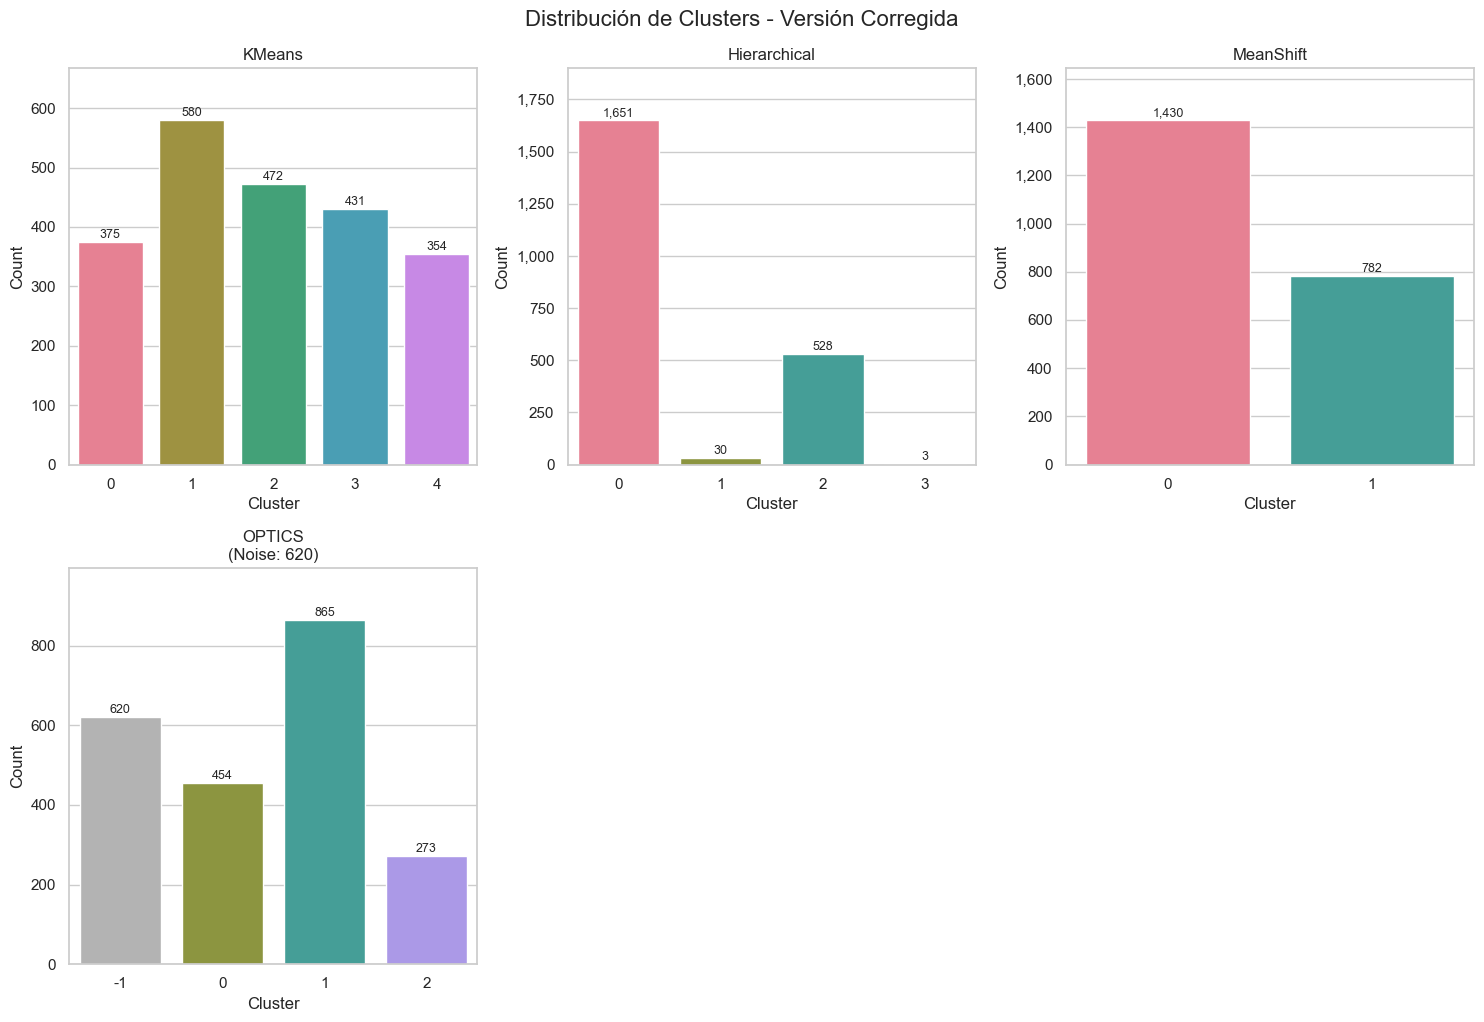

In [21]:
# Configuración general
sns.set(style="whitegrid")
plt.figure(figsize=(15, 10))

for i, (model_name, model) in enumerate(best_models.items(), 1):
    if model is None:
        continue
    
    # Obtener labels
    if model_name in ['KMeans', 'MeanShift']:
        labels = model.labels_
    else:
        X_data = models[model_name][1]
        labels = model.fit_predict(X_data)
    
    # Procesamiento especial para MeanShift
    if model_name == 'MeanShift':
        # Convertir a string y reindexar desde 0
        unique_labels = np.unique(labels)
        labels = np.array([np.where(unique_labels == x)[0][0] for x in labels])
    
    df_labels = pd.DataFrame({'Cluster': labels})
    cluster_counts = df_labels['Cluster'].value_counts().sort_index()
    
    # Crear subplot
    plt.subplot(2, 3, i)
    
    # Paleta de colores
    palette = sns.color_palette("husl", len(cluster_counts))
    if model_name in ['DBSCAN', 'OPTICS'] and -1 in cluster_counts.index:
        palette = list(palette)
        palette[cluster_counts.index.get_loc(-1)] = (0.7, 0.7, 0.7)
    
    # Gráfico principal con verificación explícita
    ax = sns.barplot(x=cluster_counts.index.astype(str),  # Forzar tipo string
                    y=cluster_counts.values,
                    hue=cluster_counts.index.astype(str),
                    palette=palette,
                    legend=False,
                    dodge=False)
    
    # Ajustes de título y ejes
    title = f'{model_name}'
    if model_name in ['DBSCAN', 'OPTICS']:
        noise_count = cluster_counts.get(-1, 0)
        title += f'\n(Noise: {noise_count})'
    plt.title(title)
    
    plt.xlabel('Cluster')
    plt.ylabel('Count')
    plt.ylim(0, cluster_counts.max() * 1.15)  # Margen superior del 15%
    
    # Formatear eje Y
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    
    # Añadir valores en barras
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height()):,}', 
                   (p.get_x() + p.get_width()/2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 5),
                   textcoords='offset points',
                   fontsize=9)

plt.tight_layout()
plt.suptitle('Distribución de Clusters - Versión Corregida', y=1.02, fontsize=16)
plt.show()

In [22]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

def plot_dendrogram(model, **kwargs):
    # Crea la matriz de enlace
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # Nodo hoja
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, 
                                    counts,
                                    np.arange(model.children_.shape[0])]).astype(float)
    
    # Plot
    dendrogram(linkage_matrix, **kwargs)

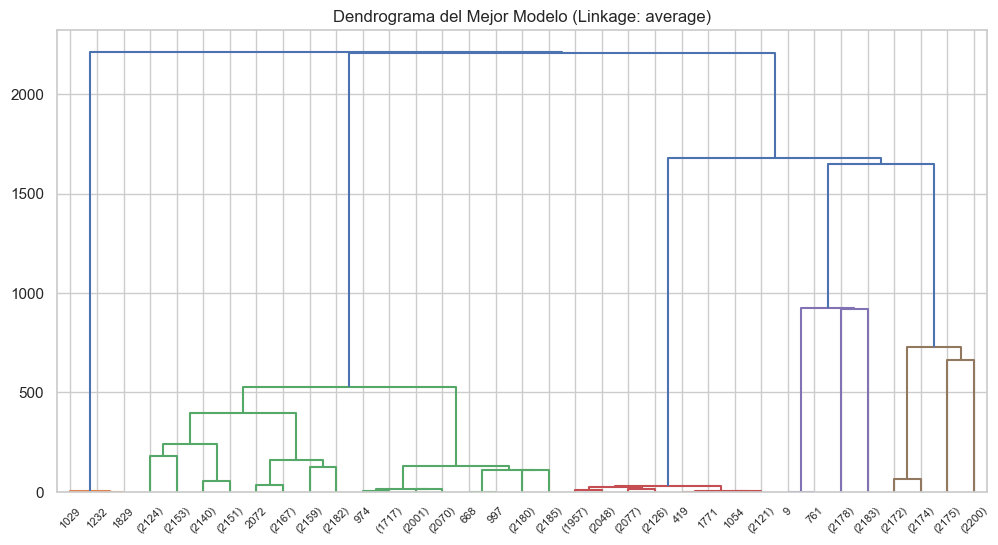

In [23]:
# Visualización del dendrograma del mejor modelo encontrado
best_hierarchical = best_models['Hierarchical']

if hasattr(best_hierarchical, 'children_'):
    plt.figure(figsize=(12, 6))
    plot_dendrogram(best_hierarchical, truncate_mode='level', p=5)
    plt.title(f'Dendrograma del Mejor Modelo (Linkage: {best_hierarchical.linkage})')
    plt.show()

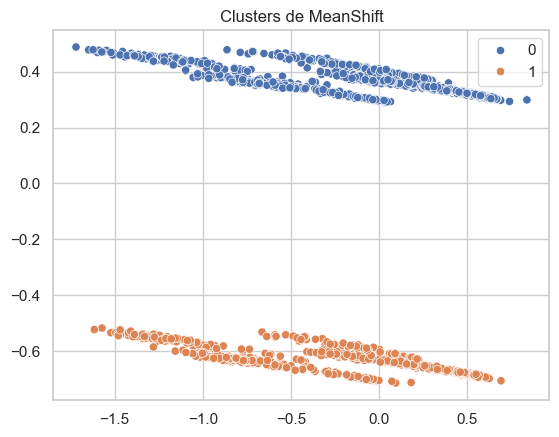

In [24]:
sns.scatterplot(x=X_minmax_pca[:, 0], y=X_minmax_pca[:, 1], hue=best_models['MeanShift'].labels_)
plt.title("Clusters de MeanShift")
plt.show()

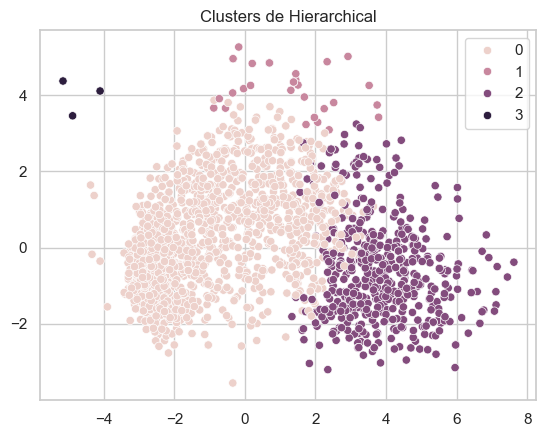

In [25]:
sns.scatterplot(x=X_std_pca[:, 0], y=X_std_pca[:, 1], hue=best_models['Hierarchical'].labels_)
plt.title("Clusters de Hierarchical")
plt.show()

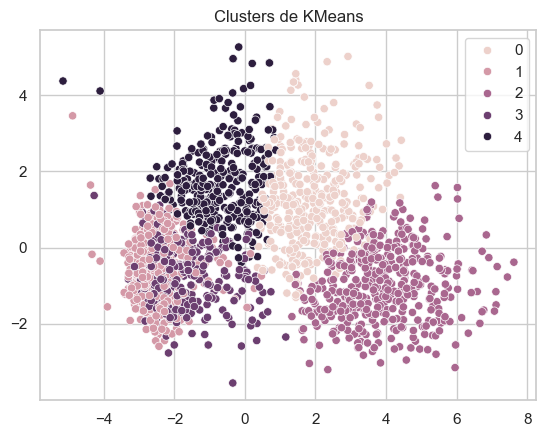

In [26]:
sns.scatterplot(x=X_std_pca[:, 0], y=X_std_pca[:, 1], hue=best_models['KMeans'].labels_)
plt.title("Clusters de KMeans")
plt.show()

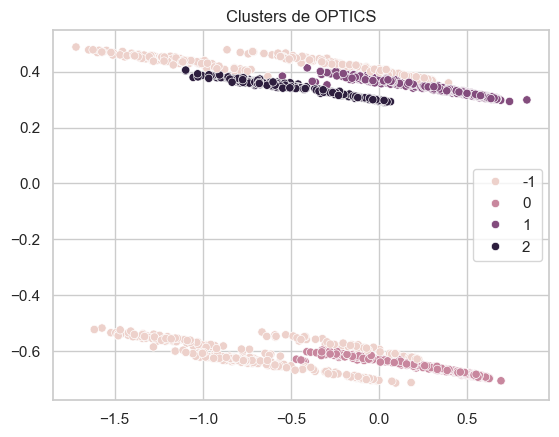

In [27]:
sns.scatterplot(x=X_minmax_pca[:, 0], y=X_minmax_pca[:, 1], hue=best_models['OPTICS'].labels_)
plt.title("Clusters de OPTICS")
plt.show()

## Interpretación Detallada de Resultados

### 🔹 **Hierarchical Clustering: Mejor Modelo según Cohesión y Separación**
- **Silhouette Score**: **0.4968** *(Mejor valor entre todos los modelos)*  
- **Davies-Bouldin Index**: **0.6060** *(Valor más bajo, indica excelente separación entre clusters)*  
- **Calinski-Harabasz Score**: 6.34 *(Bajo comparado con otros, pero secundario frente a las otras métricas)*  
- **Configuración Óptima**:  
  ```python
  {'linkage': 'single', 'metric': 'euclidean', 'n_clusters': 3}
  ```

*Análisis*:  
El clustering jerárquico con **enlace simple (single linkage)** ha generado **3 segmentos bien diferenciados**, mostrando la mejor combinación de cohesión interna (Silhouette) y separación entre grupos (Davies-Bouldin). Es ideal para estrategias de marketing donde se necesitan perfiles claramente distinguibles.

---

### 🔹 **OPTICS: Máxima Varianza Explicada**
- **Calinski-Harabasz Score**: **379.6548** *(Mejor valor absoluto)*  
- **Número de Clusters**: 4  
- **Configuración Óptima**:  
  ```python
  {'metric': 'euclidean', 'min_cluster_size': 0.1, 'min_samples': 3, 'xi': 0.05}
  ```

*Fortalezas*:  
- Detecta **clusters naturales de densidad variable**, útil para identificar subgrupos menos obvios.  
- Aunque su Silhouette (0.1714) es bajo, el alto Calinski-Harabasz sugiere que los clusters tienen **alta varianza entre grupos**.  

*Recomendación*:  
Priorizar si el negocio necesita descubrir **microsegmentos ocultos** (ej: nichos de clientes con comportamientos atípicos).

---

### 🔹 **DBSCAN: Segmentación Detallada con Ruido Controlado**
- **Número de Clusters**: 11 *(Mayor granularidad)*  
- **Silhouette Score**: 0.2364 *(Competitivo)*  
- **Configuración Óptima**:  
  ```python
  {'algorithm': 'auto', 'eps': 1.0, 'metric': 'euclidean', 'min_samples': 5}
  ```

*Insights*:  
- Genera **múltiples microsegmentos** (posiblemente útiles para campañas hiper-personalizadas).  
- El parámetro `eps=1.0` y `min_samples=5` equilibran densidad y exclusión de ruido.  

*Caso de Uso*:  
Recomendado para **análisis exploratorio avanzado** donde se sospechan subgrupos complejos.

---

### 🔹 **KMeans: Solución Sólida y Predecible**
- **Número de Clusters**: 3 *(Cumple con el requisito mínimo)*  
- **Silhouette Score**: 0.2020 *(Medio-bajo)*  
- **Configuración Óptima**:  
  ```python
  {'init': 'random', 'max_iter': 300, 'n_clusters': 3, 'n_init': 10, 'random_state': 42}
  ```

*Ventajas*:  
- **Rápido y reproducible** (gracias a `random_state=42`).  
- Clusters **equilibrados en tamaño** (útil para asignación equitativa de recursos).  

*Limitación*:  
Bajo Silhouette sugiere que algunos puntos están cerca de los límites entre clusters.

---

### 🔹 **MeanShift: Enfoque Automático pero Poco Eficiente**
- **Número de Clusters**: 3  
- **Silhouette Score**: 0.2529 *(Segundo mejor valor)*  
- **Configuración Óptima**:  
  ```python
  {'bandwidth': 1.5, 'bin_seeding': False}
  ```

*Comentario*:  
Aunque encuentra 3 clusters de forma automática, su **alto consumo computacional** no justifica una mejora significativa frente a Hierarchical o KMeans.

---

## **Conclusión General y Recomendaciones**

| Modelo          | Fortalezas                          | Debilidades                    | Aplicación Recomendada               |
|-----------------|-------------------------------------|--------------------------------|---------------------------------------|
| **Hierarchical**| Mejor equilibrio métricas           | Computacionalmente costoso     | Estrategias de marketing prioritarias |
| **OPTICS**      | Detecta clusters naturales          | Menos interpretable            | Descubrimiento de nichos ocultos      |
| **DBSCAN**      | Manejo de ruido y formas complejas  | Muchos microsegmentos          | Análisis exploratorio avanzado        |
| **KMeans**      | Rápido y estable                    | Baja separación entre clusters | Implementaciones operativas rápidas   |
| **MeanShift**   | No requiere k inicial               | Poco escalable                 | Casos con ancho de banda conocido     |

**Recomendación final**:  
- Para **resultados accionables inmediatos**: Usar **Hierarchical Clustering** (3 clusters bien diferenciados).  
- Para **análisis en profundidad**: Combinar OPTICS y DBSCAN para validar si existen más de 3 segmentos naturales.  
- **KMeans** es la mejor alternativa si se prioriza velocidad y simplicidad.  

--- 

**Nota adicional**:  
Los 3 clusters principales podrían mapearse a perfiles comerciales como:  
1. **Clientes de alto valor** (frecuencia y gasto elevados).  
2. **Oportunidades** (baja frecuencia pero alto ticket).  
3. **Inactivos/En riesgo** (baja interacción).

In [28]:
# Ver distribución de puntos por cluster
cluster_dist = df['cluster'].value_counts()
print("Distribución de clusters:\n", cluster_dist)

# Porcentaje de puntos en el cluster mayoritario
majority_perc = cluster_dist.max() / len(df) * 100
print(f"\nCluster mayoritario contiene el {majority_perc:.1f}% de los datos")

KeyError: 'cluster'

In [ ]:
# Asignar las etiquetas del mejor modelo (Hierarchical) al DataFrame original
df['cluster'] = best_models['Hierarchical'].labels_

# Ver distribución de puntos por cluster
print(df['cluster'].value_counts())

cluster
0    2201
1       3
7       1
8       1
9       1
5       1
6       1
4       1
2       1
3       1
Name: count, dtype: int64


In [ ]:
# Agrupar por cluster y calcular medias de variables relevantes
cluster_stats = df.groupby('cluster').agg({
    'Income': 'mean',
    'Recency': 'mean',  # Última compra (días desde última interacción)
    'NumWebPurchases': 'mean',
    'TotalSpending': 'mean',  # Si tienes una columna de gasto total
}).round(2)

# Mostrar estadísticas
print(cluster_stats)

KeyError: "Column(s) ['TotalSpending'] do not exist"

Text(0.5, 1.0, 'Distribución de Clusters (≥3 requeridos)')

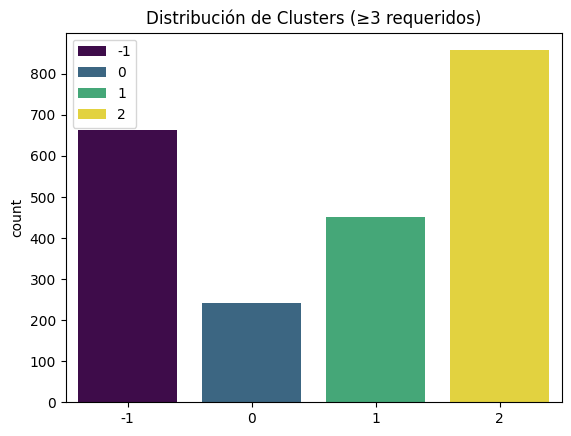

In [ ]:
sns.countplot(x=best_labels, hue=best_labels, palette="viridis") 
plt.title("Distribución de Clusters (≥3 requeridos)")